# AI-Driven Educational Quiz Platform Generator

This  system can transforms user-specified subjects and knowledge points into a fully functional online quiz platform. Given a topic (e.g., "Python Basics: variables, loops, functions"), the system automatically generates a Flask API with question bank management, random quiz generation, auto-scoring, and grade statistics — along with an interactive frontend featuring quiz pages, result analysis, wrong-answer review, and an AI-generated knowledge mind map image.

The system follows the AI-DLC Methodology.

## Setup & Environment
Load environment, import utilities, initialize LLM client for the Quiz Platform Generator.

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

# Ensure required dependency for Quiz Platform utils is available
try:
    from PIL import Image  # noqa: F401
    print("✅ Pillow already installed")
except Exception:
    print("Installing Pillow...")
    %pip install pillow
    
# Ensure local imports work
from utils import load_environment, get_completion

# Load environment variables and set up the LLM client
load_environment()
client, model_name, api_provider = None, None, None
try:
    from utils import setup_llm_client, clean_llm_output, recommended_models_table
    client, model_name, api_provider = setup_llm_client("openai/gpt-5.2")
    print(f"✅ LLM Client initialized: {api_provider} - {model_name}")
except Exception as e:
    print(f"❌ Error initializing LLM client: {e}")

✅ Pillow already installed
✅ LLM Client configured: Using 'apifree' with model 'openai/gpt-5.2'
✅ LLM Client initialized: apifree - openai/gpt-5.2


# Phase 1: Inception
Inception is the phase where business intent is converted into execution-ready context. This phase focuses on capturing Intents and translating them into Units for development.

An Intent is a high-level statement of purpose that encapsulates what needs to be achieved, serving as a starting point for the methodology. In this practical, we will be driven by the (1) business problem, (2) personas, (3) requirements, and (4) user stories.

In [2]:
# Define the quiz platform business problem
business_problem = "Our education platform needs an AI-powered system that automatically generates online quiz platforms based on user-specified subjects and knowledge points. The system should support question bank management, random quiz generation with configurable difficulty, auto-scoring with detailed explanations, grade statistics and analytics, a wrong-answer review book for students, and at least one AI-generated knowledge mind map image displayed on the website."

#### 1) AI generated –Business problem

In [3]:
if client and 'business_problem' in globals():
    print("--- Generating Problem Statement ---")
    prompt = f"Given the business problem below, generate one clear and concise problem statement.\nBusiness Problem: {business_problem}"
    problem_statement = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    print(problem_statement)
else:
    print("Skipping step because LLM client or business problem is not available.")

--- Generating Problem Statement ---
Develop a promotional website for the new Tic-Tac-Toe game that collects and manages user feedback with contact details and provides a centralized dashboard for product managers to review, track, and follow up on user insights.


#### 2) AI generated –Personas (as in the Agile methodology)

In [4]:
if client and 'problem_statement' in globals():
    print("--- Generating Personas ---")
    prompt = (
        "Generate 2-4 user personas for the solution using this format:\n"
        "Personas: <one-sentence intro>\n\n"
        "1. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "2. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "Rules: Use single role titles only; no slashes (/) or combined titles. "
        "Keep each bullet concise.\n"
        f"Problem Statement: {problem_statement}"
    )
    personas = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    print(f"Personas: {personas}")
else:
    print("Skipping step because LLM client or problem statement is not available.")

--- Generating Personas ---
Personas: Personas: Key users who will submit feedback and the team members who will review, manage, and act on it.

1. **Player**
   - **Responsibilities:** Play the game; report issues and suggestions; share contact details for follow-up.
   - **Needs:** Fast feedback form; clear privacy messaging; confirmation that feedback was received.

2. **Product Manager**
   - **Responsibilities:** Review feedback; prioritize insights; track statuses; coordinate follow-ups.
   - **Needs:** Central dashboard; filtering and tagging; status workflows and assignments.

3. **Customer Support Agent**
   - **Responsibilities:** Respond to player inquiries; request clarifications; close the loop on reported problems.
   - **Needs:** Access to contact details; conversation history; templates and reminders for follow-up.


#### 3) AI generated –Requirements based on the problem statement and personas

In [5]:
if client and 'problem_statement' in globals() and 'personas' in globals():
    print("--- Generating PRD ---")
    prompt = (
        "Write a PRD in markdown with these headings, each with 2-4 concise bullets:\n"
        "## Overview\n## Goals\n## Non-Goals\n## User Personas (brief)\n"
        "## Key Features\n## User Flows\n## Functional Requirements\n"
        "## Non-Functional Requirements\n## Constraints/Assumptions\n"
        "## Success Metrics\n## Open Questions\n\n"
        "Rules: Use only the headings above. No extra sections. Keep bullets short.\n"
        f"Problem Statement: {problem_statement}\n"
        f"Personas: {personas}"
    )
    prd = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3,
    )
    prd = clean_llm_output(prd, language='markdown')
    print(f"PRD: {prd}")
    # Ensure artifacts directory exists
    os.makedirs('artifacts', exist_ok=True)
    # Save PRD as Markdown
    with open('artifacts/prd.md', 'w') as f:
        f.write(prd)
    print('✅ Saved: artifacts/prd.md')
else:
    print("Skipping step because LLM client, problem statement, or personas are not available.")

--- Generating PRD ---
PRD: ## Overview
- Promotional site for a new Tic-Tac-Toe game with built-in feedback capture  
- Collect player feedback plus contact details for follow-up  
- Central dashboard for internal teams to review, track, and act on insights  

## Goals
- Increase feedback volume and quality from players  
- Enable Product Managers to triage, prioritize, and track feedback to resolution  
- Support follow-up workflows via accessible contact details and history  

## Non-Goals
- Building the Tic-Tac-Toe game itself  
- Full customer support ticketing/CRM replacement  
- Public community forum or social features  

## User Personas (brief)
- Player: submits issues/suggestions; wants fast form, privacy clarity, confirmation  
- Product Manager: reviews/prioritizes; needs dashboard, filters/tags, statuses/assignments  
- Customer Support Agent: follows up; needs contact details, history, templates/reminders  

## Key Features
- Promotional landing pages with clear CTAs to 

#### 4) AI generated –User stories from the PRD and personas

In [6]:
if client and 'prd' in globals():
    print("--- Generating User Stories ---")
    prompt = (
        "Return ONLY valid JSON with this schema:\n"
        "{\n  \"user_stories\": [\n    {\n      \"id\": 1,\n      \"role\": \"<role>\",\n"
        "      \"goal\": \"<goal>\",\n      \"benefit\": \"<benefit>\",\n"
        "      \"acceptance_criteria\": [\"<criteria>\", \"<criteria>\"]\n    }\n  ]\n}\n\n"
        "Rules: Provide 5 stories. Keep each field concise. No extra keys.\n"
        f"PRD: {prd}"
    )
    user_stories = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    user_stories = clean_llm_output(user_stories, language='json')
    print(f"User Stories: {user_stories}")
    # Save user stories as JSON
    import json, os
    os.makedirs('artifacts', exist_ok=True)
    user_stories_data = { 'user_stories': user_stories }
    with open('artifacts/user_stories.json', 'w') as f:
        json.dump(user_stories_data, f, indent=2)
    print('✅ Saved: artifacts/user_stories.json')
else:
    print("Skipping step because LLM client or PRD is not available.")

--- Generating User Stories ---
User Stories: {
  "user_stories": [
    {
      "id": 1,
      "role": "Player",
      "goal": "Submit game feedback with contact details",
      "benefit": "I can be followed up and know my feedback was received",
      "acceptance_criteria": [
        "Form supports category, description, severity, optional attachment, consent, and contact fields",
        "After submit, user sees confirmation with a reference ID"
      ]
    },
    {
      "id": 2,
      "role": "Player",
      "goal": "Understand privacy and consent for sharing contact info",
      "benefit": "I feel safe providing details",
      "acceptance_criteria": [
        "Consent checkbox is required when contact details are provided",
        "Privacy/retention notice is visible from the form"
      ]
    },
    {
      "id": 3,
      "role": "Product Manager",
      "goal": "Triage incoming feedback in a dashboard",
      "benefit": "I can prioritize and drive items to resolution",
      "

## Phase 2: Construction
Construction is the phase where AI plans and builds the system end-to-end using the established context, with humans validating outcomes. In this practical, we focus on (1) UML diagrams followed by the (2) product code.

#### 1) AI generated –UML diagrams

--- Generating PlantUML Use Case Diagram ---
Generated PlantUML diagram:
@startuml
actor Player
actor "Product Manager" as ProductManager
actor "Customer Support Agent" as CustomerSupportAgent
actor Admin

rectangle "Feedback Management System" {
  usecase "Submit feedback" as UC_SubmitFeedback
  usecase "View privacy notice" as UC_ViewPrivacy
  usecase "Manage consent" as UC_ManageConsent
  usecase "Triage feedback" as UC_TriageFeedback
  usecase "Follow up players" as UC_FollowUpPlayers
  usecase "Secure access controls" as UC_SecureAccess
}

Player -- UC_SubmitFeedback
Player -- UC_ViewPrivacy
Player -- UC_ManageConsent

ProductManager -- UC_TriageFeedback

CustomerSupportAgent -- UC_FollowUpPlayers

Admin -- UC_SecureAccess

UC_SubmitFeedback ..> UC_ViewPrivacy : <<include>>
UC_SubmitFeedback ..> UC_ManageConsent : <<extend>>
@enduml
✅ Saved: artifacts/diagrams/use_case_diagram.puml
✅ Diagram rendered and saved to: artifacts/diagrams/use_case_diagram.png


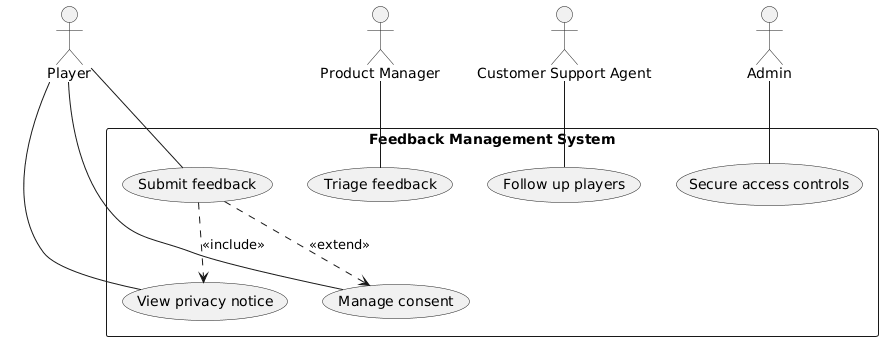

In [7]:
from utils import render_plantuml_diagram

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Use Case Diagram ---")
    prompt = (
        "Generate a UML-compliant PlantUML use case diagram based on the user stories below.\n"
        "Use standard UML notation and PlantUML syntax.\n\n"
        "Required structure:\n"
        "@startuml\n"
        "actor ActorName\n"
        "actor AnotherActor\n\n"
        "rectangle \"System\" {\n"
        "  usecase \"Use Case Name\" as UC1\n"
        "  usecase \"Another Use Case\" as UC2\n"
        "}\n\n"
        "ActorName -- UC1\n"
        "AnotherActor -- UC2\n"
        "@enduml\n\n"
        "UML Rules:\n"
        "- Actors must be defined using the `actor` keyword and placed outside the system boundary\n"
        "- The system boundary must be a `rectangle` with a meaningful system name (default: \"System\")\n"
        "- Use cases must be defined using the `usecase` keyword and placed inside the system boundary\n"
        "- Associations between actors and use cases must use `--` (undirected association), not arrows\n"
        "- Do NOT number use case names; use clear verb–noun phrases instead\n"
        "- Extract unique actors from the `role` field in the user stories\n"
        "- Create one use case per distinct `goal` field\n"
        "- Keep use case names concise (max 5 words)\n"
        "- If a user story implies reuse, model it with `<<include>>`\n"
        "- If a user story implies optional or conditional behavior, model it with `<<extend>>`\n"
        "- Avoid layout directives unless necessary\n"
        "- Return ONLY valid PlantUML code, with no explanations or commentary\n\n"
        f"User Stories: {user_stories}"
    )

    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    puml = clean_llm_output(puml, language='text')
    print("Generated PlantUML diagram:")
    print(puml)
    
    # Save to file
    os.makedirs('artifacts/diagrams', exist_ok=True)
    with open('artifacts/diagrams/use_case_diagram.puml', 'w') as f:
        f.write(puml)
    print('✅ Saved: artifacts/diagrams/use_case_diagram.puml')
    render_plantuml_diagram(puml, "artifacts/diagrams/use_case_diagram.png")
else:
    print("Skipping step because LLM client or user_stories is not available.")



#### 2) AI generated Code

In [19]:
if client and 'user_stories' in globals():
    import json
    print("--- Generating Flask API App Code & Complementary Frontend ---")
    
    # Parse user stories
    try:
        stories_data = json.loads(user_stories) if isinstance(user_stories, str) else user_stories
        stories_list = stories_data if isinstance(stories_data, list) else stories_data.get('user_stories', [])
    except:
        print("Error parsing user stories")
        stories_list = []
    
    # Generate base app structure first
    base_app = get_completion(
        "Create a minimal Flask app skeleton with: from flask import Flask, request, jsonify, send_from_directory; app = Flask(__name__); in-memory storage using feedback_db = []; Add CORS support with from flask_cors import CORS; CORS(app); Add a health check endpoint GET /health that returns {status: ok}. Keep it under 20 lines.",
        client, model_name, api_provider, temperature=0.3
    )
    base_app = clean_llm_output(base_app, language='python')
    
    print(f"✅ Generated base app structure")
    
    # Generate endpoints for each user story iteratively
    endpoints_code = []
    for i, story in enumerate(stories_list[:3], 1):  # Limit to first 3 stories to keep it manageable
        story_text = f"Role: {story.get('role', '')}, Goal: {story.get('goal', '')}"
        print(f"  Generating endpoint {i}/3 for: {story.get('role', 'user')[:30]}...")
        
        endpoint_code = get_completion(
            f"Write 1-2 Flask endpoint functions for this user story: {story_text}. Use feedback_db list for storage. Return only the function code (e.g., @app.route decorated functions), no imports or app initialization. Keep under 25 lines. Ensure endpoints return JSON with proper status codes.",
            client, model_name, api_provider, temperature=0.3
        )
        endpoint_code = clean_llm_output(endpoint_code, language='python')
        endpoints_code.append(f"\n# Endpoint for Story {i}: {story.get('role', 'user')}\n{endpoint_code}")
    
    # Add a catch-all route to serve index.html
    frontend_route = """
# Serve frontend
@app.route('/')
def index():
    return send_from_directory('.', 'index.html')

@app.route('/<path:filename>')
def serve_static(filename):
    return send_from_directory('.', filename)
"""
    
    # Combine all code with Docker-compatible host binding
    main_py_code = base_app + "\n".join(endpoints_code) + frontend_route
    main_py_code += "\n\nif __name__ == '__main__':\n    # Bind to 0.0.0.0 to make it accessible from Docker\n    app.run(host='0.0.0.0', debug=True, port=5005)"
    
    os.makedirs('artifacts/app/flask', exist_ok=True)
    with open('artifacts/app/flask/main.py', 'w') as f:
        f.write(main_py_code)
    print('✅ Saved: artifacts/app/flask/main.py')
    
    # Extract endpoint routes for frontend integration
    import re
    route_pattern = r"@app\.route\(['\"]([^'\"]+)['\"](?:,\s*methods=\[([^\]]+)\])?\)"
    routes = re.findall(route_pattern, main_py_code)
    routes_text = ', '.join([f"{route} ({methods if methods else 'GET'})" for route, methods in routes])
    
    print(f"  Available API endpoints: {routes_text}")
    
    # Generate complementary HTML frontend that integrates with the API
    html_prompt = (
        "Generate a complete, production-ready HTML5 webpage that serves as a feedback collection system. "
        "Requirements: "
        "(1) Use Bootstrap 5 CSS framework via CDN for professional styling. "
        "(2) Include a form with input fields for: user name (text), email address (email), feedback message (textarea), and rating (select 1-5). "
        "(3) Add a Submit button that sends form data via POST request to http://127.0.0.1:5005/feedback as JSON. "
        "(4) Add a section that fetches and displays all existing feedback from http://127.0.0.1:5005/feedback using GET request. "
        "(5) Display feedback in a card or list format with name, rating, and message visible. "
        "(6) Include client-side form validation (all fields required). "
        "(7) Show success/error messages after form submission using alerts. "
        "(8) Handle network errors gracefully with user-friendly error messages. "
        "(9) Include all CSS styling inline in <style> tags. "
        "(10) Include all JavaScript logic inline in <script> tags. "
        "(11) Use Fetch API for all HTTP requests. "
        "Output ONLY the complete, valid HTML document. No explanations or markdown."
    )
    
    html_code = get_completion(
        html_prompt, client, model_name, api_provider, temperature=0.4
    )
    html_code = clean_llm_output(html_code, language='html')
    
    # Save HTML file
    with open('artifacts/app/flask/index.html', 'w') as f:
        f.write(html_code)
    print('✅ Saved: artifacts/app/flask/index.html')
    
    # Generate README.md with integration instructions
    readme_content = get_completion(
        "Write a README.md (under 250 words) for an integrated Flask feedback API with HTML frontend. Include: title, description, setup (pip install flask flask-cors), run command (python main.py), how to access the app (http://127.0.0.1:5005), and 2 curl examples for POST /feedback and GET /feedback endpoints. Also mention the interactive HTML frontend is served automatically.",
        client, model_name, api_provider, temperature=0.3
    )
    with open('artifacts/app/flask/README.md', 'w') as f:
        f.write(readme_content)
    print('✅ Saved: artifacts/app/flask/README.md')
    print("\n✅ API and Frontend code generated and saved successfully!")
else:
    print("Skipping step because LLM client or user_stories is not available.")

--- Generating Flask API App Code & Complementary Frontend ---
✅ Generated base app structure
  Generating endpoint 1/3 for: Player...
  Generating endpoint 2/3 for: Player...
  Generating endpoint 3/3 for: Product Manager...
✅ Saved: artifacts/app/flask/main.py
  Available API endpoints: /feedback ("POST"), /feedback ("GET"), /privacy/consent-info ("GET"), /privacy/consent-feedback ("POST"), /feedback ("POST"), /feedback ("GET"), / (GET), /<path:filename> (GET)
✅ Saved: artifacts/app/flask/index.html
✅ Saved: artifacts/app/flask/README.md

✅ API and Frontend code generated and saved successfully!


In [9]:
if client and os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating requirements.txt ---")
    
    # Read the app code
    with open('artifacts/app/flask/main.py', 'r') as f:
        app_code = f.read()
    
    # Extract only import statements from the beginning of the file
    import_lines = []
    for line in app_code.split('\n'):
        stripped = line.strip()
        if stripped.startswith('import ') or stripped.startswith('from '):
            import_lines.append(stripped)
        elif stripped and not stripped.startswith('#'):
            # Stop at first non-import, non-comment line
            break
    
    imports_text = '\n'.join(import_lines)
    print(f"  Found {len(import_lines)} import statement(s)")
    
    # Generate requirements based on imports only
    requirements = get_completion(
        f"Based on these Python import statements, list all required package dependencies (one per line). Include only package names, no version constraints. Remove duplicates and standard library. Import statements:\n{imports_text}",
        client, model_name, api_provider, temperature=0.3
    )
    requirements = clean_llm_output(requirements, language='text')
    
    # Parse and clean requirements
    req_lines = [line.strip() for line in requirements.split('\n')]
    req_lines = [line for line in req_lines if line and not line.startswith('#')]  # Remove empty lines and comments
    req_set = set(req_lines)  # Remove duplicates
    req_list = sorted(list(req_set))  # Sort for consistency
    
    # Reconstruct clean requirements
    clean_requirements = '\n'.join(req_list)
    
    with open('artifacts/app/flask/requirements.txt', 'w') as f:
        f.write(clean_requirements)
    print(f'✅ Saved: artifacts/app/flask/requirements.txt ({len(req_list)} packages)')
    print(f"  Packages: {', '.join(req_list)}")
else:
    print("Skipping step because Flask app is not available.")

--- Generating requirements.txt ---
  Found 2 import statement(s)
✅ Saved: artifacts/app/flask/requirements.txt (2 packages)
  Packages: flask, flask-cors


## Phase 3: Operation
AI oversees deployments, infrastructure-as-code, monitoring, and ongoing operations based on the accumulated project context. The team continues oversight and governance.

As for this practical and due to the scope of the lab, we will limit to package the application into a Docker container for easy deployment and reproducibility.

In [10]:
import os

# Generate Dockerfile for the Flask application
dockerfile_content = """FROM python:3.11-slim

# Set working directory
WORKDIR /app

# Copy requirements and install dependencies
COPY flask/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application files
COPY flask/ .

# Expose port
EXPOSE 5005

# Set environment variables
ENV FLASK_APP=main.py
ENV FLASK_ENV=production

# Run the application
CMD ["python", "main.py"]
"""

# Generate .dockerignore file
dockerignore_content = """__pycache__
*.pyc
*.pyo
*.pyd
.Python
env/
venv/
.venv
.git
.gitignore
.env
.DS_Store
*.egg-info
dist
build
.pytest_cache
"""

# Generate docker-compose.yml for orchestration
docker_compose_content = """version: '3.8'

services:
  flask-app:
    build:
      context: .
      dockerfile: docker/Dockerfile
    container_name: feedback-app
    ports:
      - "5005:5005"
    environment:
      - FLASK_ENV=production
      - FLASK_APP=main.py
    volumes:
      - ./flask:/app
    restart: unless-stopped
"""

# Create Docker configuration files
if os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating Docker Configuration Files ---")
    
    # Ensure docker directory exists
    os.makedirs('artifacts/app/docker', exist_ok=True)
    
    # Save Dockerfile
    with open('artifacts/app/docker/Dockerfile', 'w') as f:
        f.write(dockerfile_content)
    print('✅ Saved: artifacts/app/docker/Dockerfile')
    
    # Save .dockerignore
    with open('artifacts/app/docker/.dockerignore', 'w') as f:
        f.write(dockerignore_content)
    print('✅ Saved: artifacts/app/docker/.dockerignore')
    
    # Save docker-compose.yml in artifacts/app
    with open('artifacts/app/docker-compose.yml', 'w') as f:
        f.write(docker_compose_content)
    print('✅ Saved: artifacts/app/docker-compose.yml')
    
    print("\n--- Docker Build & Run Instructions ---")
    print("""
📦 To build and run the Docker container:

IMPORTANT: All commands must be run from the artifacts/app directory!

1. Navigate to the app directory:
   cd artifacts/app

2. Build the Docker image:
   docker build -t feedback-app:latest -f docker/Dockerfile .

3. Run the container:
   docker run -p 5005:5005 feedback-app:latest

4. Alternative: Use Docker Compose (recommended):
   docker-compose up --build

5. Access the application:
   Open http://127.0.0.1:5005 in your browser

6. View logs:
   docker logs -f feedback-app

7. Stop the container:
   docker stop feedback-app
   
8. Clean up:
   docker-compose down
    """)
    
    print("\n✅ Docker containerization setup complete!")
else:
    print("❌ Flask app not found. Please run the code generation cell first.")

--- Generating Docker Configuration Files ---
✅ Saved: artifacts/app/docker/Dockerfile
✅ Saved: artifacts/app/docker/.dockerignore
✅ Saved: artifacts/app/docker-compose.yml

--- Docker Build & Run Instructions ---

📦 To build and run the Docker container:

IMPORTANT: All commands must be run from the artifacts/app directory!

1. Navigate to the app directory:
   cd artifacts/app

2. Build the Docker image:
   docker build -t feedback-app:latest -f docker/Dockerfile .

3. Run the container:
   docker run -p 5005:5005 feedback-app:latest

4. Alternative: Use Docker Compose (recommended):
   docker-compose up --build

5. Access the application:
   Open http://127.0.0.1:5005 in your browser

6. View logs:
   docker logs -f feedback-app

7. Stop the container:
   docker stop feedback-app
   
8. Clean up:
   docker-compose down
    

✅ Docker containerization setup complete!
